### Задание
1. Обучите word-level RNN language model на собственном тексте Джейн Остин.
2. Постройте график training loss.
3. Сгенерируйте тексты:
   - greedy
   - sampling
   - sampling with temperature
   - sampling with top-k
4. Сравните качество генерации.
5. (Опционально) замените RNN на LSTM и сравните результаты.

0А) Загрузка текста Вечера на хуторе близ Диканьки Гоголь

In [1]:
import requests

In [2]:
YANDEX_URL = "https://disk.yandex.ru/d/jgpiPGPAZ6W7rg"

In [3]:
def download_yandex_text(YANDEX_URL:str) -> str:
  api_url = "https://cloud-api.yandex.net/v1/disk/public/resources/download"
  params = {"public_key": YANDEX_URL}
  response = requests.get(api_url, params=params, timeout=30)
  data = response.json()
  raw = requests.get(data.get('href'),timeout=30).content
  return raw.decode("UTF-8")

In [4]:
gogal_prose = download_yandex_text("https://disk.yandex.ru/d/nThp_jS1gq7UhA")
print(gogal_prose[:200]+'\n')

     "Это  что  за  невидаль: "Вечера на хуторе близ Диканьки"?
Что это за "Вечера"? И швырнул в свет какой-то пасечник!  Слава
богу!  еще  мало  ободрали  гусей  на  перья и извели тряпья на
бумаг



In [5]:
import re
import math
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


0Б) Подготовим токины, НЕ используем лемматизацию или стемминг, НЕ удаляем стоп-слова

In [6]:
TOKEN_RE = re.compile(r"[А-Яа-яЁё]+(?:'[А-Яа-яЁё]+)?")
def tokenize(text):
    text = text.lower()
    tokens = re.findall(TOKEN_RE, text)
    return tokens


In [7]:
tokens = tokenize(gogal_prose)
print(tokens[:50])
print("Number of tokens:", len(tokens))
print("Number of unique raw tokens:", len(set(tokens)))

['это', 'что', 'за', 'невидаль', 'вечера', 'на', 'хуторе', 'близ', 'диканьки', 'что', 'это', 'за', 'вечера', 'и', 'швырнул', 'в', 'свет', 'какой', 'то', 'пасечник', 'слава', 'богу', 'еще', 'мало', 'ободрали', 'гусей', 'на', 'перья', 'и', 'извели', 'тряпья', 'на', 'бумагу', 'еще', 'мало', 'народу', 'всякого', 'звания', 'и', 'сброду', 'вымарало', 'пальцы', 'в', 'чернилах', 'дернула', 'же', 'охота', 'и', 'пасичника', 'дотащиться']
Number of tokens: 26062
Number of unique raw tokens: 8324


Тест 1

In [9]:
MAX_TOKENS = 500_000     # можно увеличить до 100_000 или больше
MAX_VOCAB = 5000

tokens = tokens[:MAX_TOKENS]
print("Using tokens:", len(tokens))

counter = Counter(tokens)
most_common = counter.most_common(MAX_VOCAB - 2)  # reserving <pad>, <unk>

itos = ["<pad>", "<unk>"] + [w for w, _ in most_common]
stoi = {w: i for i, w in enumerate(itos)}

PAD_ID = stoi["<pad>"]
UNK_ID = stoi["<unk>"]

def encode_token(tok):
    return stoi.get(tok, UNK_ID)

ids = [encode_token(tok) for tok in tokens]

print("Vocab size:", len(itos))
print("First 30 ids:", ids[:30])

Using tokens: 26062
Vocab size: 5000
First 30 ids: [17, 6, 12, 2611, 352, 5, 967, 1437, 968, 6, 17, 12, 352, 2, 969, 3, 595, 108, 10, 1438, 405, 150, 26, 129, 2612, 970, 5, 2613, 2, 2614]


In [10]:
SEQ_LEN = 30
TRAIN_FRAC = 0.9
BATCH_SIZE = 32

class LanguageModelingDataset(Dataset):
    def __init__(self, ids, seq_len):
        self.ids = ids
        self.seq_len = seq_len

    def __len__(self):
        return len(self.ids) - self.seq_len

    def __getitem__(self, idx):
        x = torch.tensor(self.ids[idx: idx + self.seq_len], dtype=torch.long)
        y = torch.tensor(self.ids[idx + 1: idx + self.seq_len + 1], dtype=torch.long)
        return x, y

split_idx = int(len(ids) * TRAIN_FRAC)
train_ids = ids[:split_idx]
test_ids = ids[split_idx:]

train_dataset = LanguageModelingDataset(train_ids, SEQ_LEN)
test_dataset = LanguageModelingDataset(test_ids, SEQ_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

print("Train tokens:", len(train_ids))
print("Test tokens:", len(test_ids))
print("Train examples:", len(train_dataset))
print("Test examples:", len(test_dataset))

xb, yb = next(iter(train_loader))
print("xb shape:", xb.shape)
print("yb shape:", yb.shape)

Train tokens: 23455
Test tokens: 2607
Train examples: 23425
Test examples: 2577
xb shape: torch.Size([32, 30])
yb shape: torch.Size([32, 30])


## Shapes in the model

- input ids: `(batch_size, seq_len)`
- embeddings: `(batch_size, seq_len, emb_dim)`
- RNN hidden states: `(batch_size, seq_len, hidden_dim)`
- output logits: `(batch_size, seq_len, vocab_size)`

На каждом шаге модель предсказывает распределение по всему словарю.

In [11]:
class WordRNN(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.RNN(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )
        self.out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h0=None):
        # x: (B, L)
        x = self.emb(x)          # (B, L, E)
        h, h_n = self.rnn(x, h0) # h: (B, L, H)
        logits = self.out(h)     # (B, L, V)
        return logits, h_n

In [12]:
VOCAB_SIZE = len(itos)
EMB_DIM = 64
HIDDEN_DIM = 128

model = WordRNN(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM).to(device)
model

WordRNN(
  (emb): Embedding(5000, 64)
  (rnn): RNN(64, 128, batch_first=True)
  (out): Linear(in_features=128, out_features=5000, bias=True)
)

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [14]:
xb, yb = next(iter(train_loader))
xb = xb.to(device)
yb = yb.to(device)

logits, h_n = model(xb)

print("logits shape:", logits.shape)  # (B, L, V)
#print("h_n shape:", h_n.shape)        # (1, B, H)

loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
print("loss:", float(loss))

logits shape: torch.Size([32, 30, 5000])
loss: 8.545145988464355


/tmp/ipykernel_3371/488190934.py:11: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print("loss:", float(loss))


In [15]:
@torch.no_grad()
def evaluate(model, loader, criterion, device, vocab_size):
    model.eval()
    total_loss = 0.0
    total_batches = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits, _ = model(xb)
        loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))

        total_loss += loss.item()
        total_batches += 1

    mean_loss = total_loss / total_batches
    ppl = math.exp(mean_loss)
    return mean_loss, ppl


EPOCHS = 10

train_losses = []
test_losses = []
train_ppls = []
test_ppls = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_ppl = math.exp(train_loss)

    test_loss, test_ppl = evaluate(model, test_loader, criterion, device, VOCAB_SIZE)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_ppls.append(train_ppl)
    test_ppls.append(test_ppl)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train loss = {train_loss:.4f} | train ppl = {train_ppl:.2f} | "
        f"test loss = {test_loss:.4f} | test ppl = {test_ppl:.2f}"
    )

Epoch 1/10 | train loss = 5.7275 | train ppl = 307.21 | test loss = 6.1343 | test ppl = 461.40
Epoch 2/10 | train loss = 3.1394 | train ppl = 23.09 | test loss = 6.7728 | test ppl = 873.80
Epoch 3/10 | train loss = 1.7570 | train ppl = 5.80 | test loss = 7.5087 | test ppl = 1823.84
Epoch 4/10 | train loss = 1.0994 | train ppl = 3.00 | test loss = 8.1687 | test ppl = 3528.69
Epoch 5/10 | train loss = 0.7580 | train ppl = 2.13 | test loss = 8.7509 | test ppl = 6316.38
Epoch 6/10 | train loss = 0.5684 | train ppl = 1.77 | test loss = 9.2518 | test ppl = 10423.28
Epoch 7/10 | train loss = 0.4560 | train ppl = 1.58 | test loss = 9.6662 | test ppl = 15775.86
Epoch 8/10 | train loss = 0.3853 | train ppl = 1.47 | test loss = 10.0464 | test ppl = 23072.33
Epoch 9/10 | train loss = 0.3386 | train ppl = 1.40 | test loss = 10.3652 | test ppl = 31735.58
Epoch 10/10 | train loss = 0.3058 | train ppl = 1.36 | test loss = 10.6267 | test ppl = 41220.89


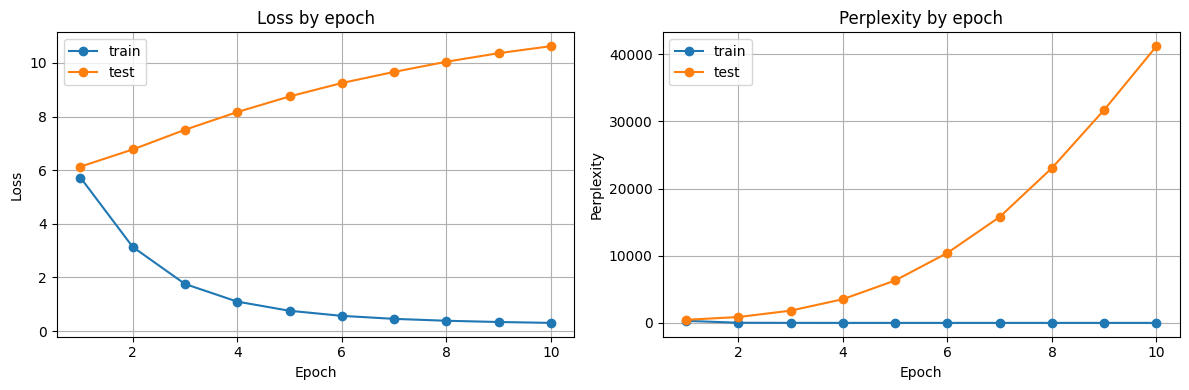

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(train_losses) + 1), train_losses, marker="o", label="train")
axes[0].plot(range(1, len(test_losses) + 1), test_losses, marker="o", label="test")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss by epoch")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(range(1, len(train_ppls) + 1), train_ppls, marker="o", label="train")
axes[1].plot(range(1, len(test_ppls) + 1), test_ppls, marker="o", label="test")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Perplexity")
axes[1].set_title("Perplexity by epoch")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
def decode_ids(id_list):
    return " ".join(itos[i] for i in id_list)

def sample_from_logits(logits, method="greedy", temperature=1.0, top_k=None):
    """
    logits: tensor of shape (V,)
    """
    logits = logits.detach().cpu()

    if method == "greedy":
        return int(torch.argmax(logits).item())

    # temperature
    logits = logits / temperature

    # top-k
    if top_k is not None:
        values, indices = torch.topk(logits, k=min(top_k, logits.shape[0]))
        probs = torch.softmax(values, dim=0)
        chosen = torch.multinomial(probs, num_samples=1).item()
        return int(indices[chosen].item())

    # plain sampling
    probs = torch.softmax(logits, dim=0)
    return int(torch.multinomial(probs, num_samples=1).item())

In [18]:
@torch.no_grad()
def generate_text(
    model,
    prompt,
    max_new_tokens=30,
    method="greedy",
    temperature=1.0,
    top_k=None
):
    model.eval()

    prompt_tokens = re.findall(r"\w+|[^\w\s]", prompt.lower(), re.UNICODE)
    if len(prompt_tokens) == 0:
        raise ValueError("Prompt is empty after tokenization.")

    input_ids = [stoi.get(tok, UNK_ID) for tok in prompt_tokens]
    generated = input_ids[:]

    # Сначала прогоняем весь prompt, чтобы получить состояние
    x = torch.tensor([generated], dtype=torch.long, device=device)
    logits, h = model(x)

    # Последний логит соответствует предсказанию после последнего токена prompt
    next_logits = logits[0, -1]

    for _ in range(max_new_tokens):
        next_id = sample_from_logits(
            next_logits,
            method=method,
            temperature=temperature,
            top_k=top_k
        )
        generated.append(next_id)

        # Следующий шаг: подаём только последний токен и продолжаем с тем же hidden state
        x_next = torch.tensor([[next_id]], dtype=torch.long, device=device)
        logits, h = model(x_next, h)
        next_logits = logits[0, -1]

    return decode_ids(generated)

In [19]:
prompt = "какую шапку надел"
print(generate_text(model, prompt, max_new_tokens=40, method="greedy"))

какую шапку надел на себя этот добрый молодец увеличившийся шум и хохот заставили очнуться наших мертвецов солопия и его супругу которые полные прошедшего испуга долго глядели в ужасе неподвижными глазами на смуглые лица цыган озаряясь светом неверно и трепетно горевшим они казались диким


In [20]:
prompt = "На ярмарке случилось"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling"))

на ярмарке случилось странное происшествие все наполнилось слухом что уже и то что ни расскажешь ни ни тебе то а ну гоп трала гоп трала гоп гоп гоп вот одурел человек добро бы еще <unk> какой а то старый <unk> <unk> на смех


In [21]:
prompt = "она любит яблоки"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling"))

она любит <unk> <unk> <unk> сват отдохнуть сказал винокур <unk> его за руку это <unk> человек <unk> такого народу и <unk> наша славно бы пошла <unk> люди на длинные же скорее жених в согласие люди на угрюмых лицах которых кажется век не проскальзывала


In [23]:
prompt = "За Фомою Григорьевичем водилась"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling", top_k=10))

за фомою григорьевичем водилась особенного рода странность он до смерти не любил пересказывать одно и то же бывало иногда если упросишь его рассказать что сызнова то смотри что нибудь да тебя а не немного пришел говорил он садясь на лавку у дверей и не


Наблюдение: Тест 1(EMB_DIM = 64, HIDDEN_DIM = 128) показывает, что происходит переобучения уже на Epoch 2. На тестовом наборе растет ошибка. По промтам:
- greedy точно предсказывает текст из произведения.
- "на ярмарке" sampling вначале предсказал хорошо, но потом возникли голюцинации,повторы, неграмотно. пример:  "гоп трала гоп трала гоп гоп гоп"
- "она любит яблоки" sampling незнакомый текст, много унков
- "Фома" sampling top_k=10 неплохо предсказал текст

Тест 2

In [26]:
VOCAB_SIZE = len(itos)
EMB_DIM = 16
HIDDEN_DIM = 16

model = WordRNN(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM).to(device)
model

WordRNN(
  (emb): Embedding(5000, 16)
  (rnn): RNN(16, 16, batch_first=True)
  (out): Linear(in_features=16, out_features=5000, bias=True)
)

In [27]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [29]:
xb, yb = next(iter(train_loader))
xb = xb.to(device)
yb = yb.to(device)

logits, h_n = model(xb)

print("logits shape:", logits.shape)  # (B, L, V)
#print("h_n shape:", h_n.shape)        # (1, B, H)

loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
print("loss:", float(loss))

logits shape: torch.Size([32, 30, 5000])
loss: 8.5753173828125


In [30]:
@torch.no_grad()
def evaluate(model, loader, criterion, device, vocab_size):
    model.eval()
    total_loss = 0.0
    total_batches = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits, _ = model(xb)
        loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))

        total_loss += loss.item()
        total_batches += 1

    mean_loss = total_loss / total_batches
    ppl = math.exp(mean_loss)
    return mean_loss, ppl


EPOCHS = 10

train_losses = []
test_losses = []
train_ppls = []
test_ppls = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_ppl = math.exp(train_loss)

    test_loss, test_ppl = evaluate(model, test_loader, criterion, device, VOCAB_SIZE)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_ppls.append(train_ppl)
    test_ppls.append(test_ppl)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train loss = {train_loss:.4f} | train ppl = {train_ppl:.2f} | "
        f"test loss = {test_loss:.4f} | test ppl = {test_ppl:.2f}"
    )

Epoch 1/10 | train loss = 6.8905 | train ppl = 982.86 | test loss = 6.0926 | test ppl = 442.55
Epoch 2/10 | train loss = 6.3517 | train ppl = 573.49 | test loss = 6.0806 | test ppl = 437.28
Epoch 3/10 | train loss = 5.9562 | train ppl = 386.13 | test loss = 6.1303 | test ppl = 459.59
Epoch 4/10 | train loss = 5.5749 | train ppl = 263.72 | test loss = 6.2032 | test ppl = 494.35
Epoch 5/10 | train loss = 5.2501 | train ppl = 190.59 | test loss = 6.3005 | test ppl = 544.86
Epoch 6/10 | train loss = 4.9815 | train ppl = 145.69 | test loss = 6.3985 | test ppl = 600.96
Epoch 7/10 | train loss = 4.7649 | train ppl = 117.32 | test loss = 6.5065 | test ppl = 669.46
Epoch 8/10 | train loss = 4.5913 | train ppl = 98.63 | test loss = 6.6056 | test ppl = 739.23
Epoch 9/10 | train loss = 4.4520 | train ppl = 85.79 | test loss = 6.7057 | test ppl = 817.04
Epoch 10/10 | train loss = 4.3373 | train ppl = 76.50 | test loss = 6.8010 | test ppl = 898.72


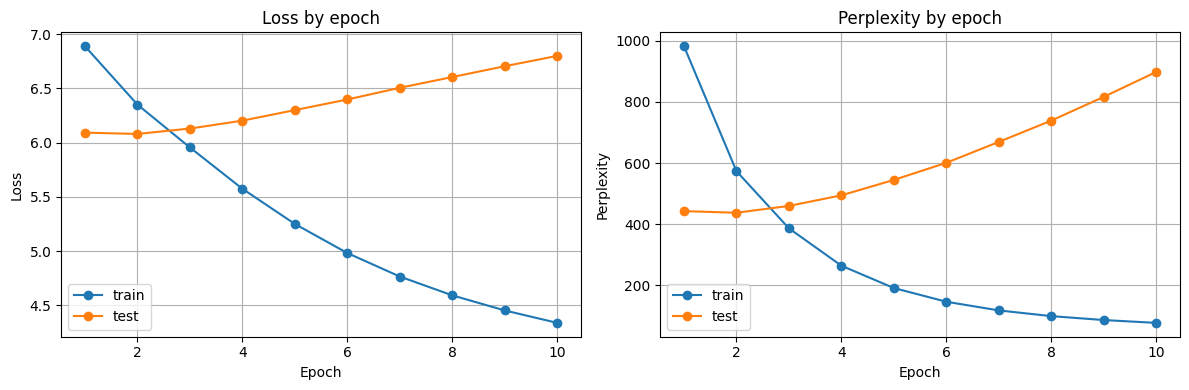

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(train_losses) + 1), train_losses, marker="o", label="train")
axes[0].plot(range(1, len(test_losses) + 1), test_losses, marker="o", label="test")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss by epoch")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(range(1, len(train_ppls) + 1), train_ppls, marker="o", label="train")
axes[1].plot(range(1, len(test_ppls) + 1), test_ppls, marker="o", label="test")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Perplexity")
axes[1].set_title("Perplexity by epoch")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [32]:
def decode_ids(id_list):
    return " ".join(itos[i] for i in id_list)

def sample_from_logits(logits, method="greedy", temperature=1.0, top_k=None):
    """
    logits: tensor of shape (V,)
    """
    logits = logits.detach().cpu()

    if method == "greedy":
        return int(torch.argmax(logits).item())

    # temperature
    logits = logits / temperature

    # top-k
    if top_k is not None:
        values, indices = torch.topk(logits, k=min(top_k, logits.shape[0]))
        probs = torch.softmax(values, dim=0)
        chosen = torch.multinomial(probs, num_samples=1).item()
        return int(indices[chosen].item())

    # plain sampling
    probs = torch.softmax(logits, dim=0)
    return int(torch.multinomial(probs, num_samples=1).item())

In [33]:
@torch.no_grad()
def generate_text(
    model,
    prompt,
    max_new_tokens=30,
    method="greedy",
    temperature=1.0,
    top_k=None
):
    model.eval()

    prompt_tokens = re.findall(r"\w+|[^\w\s]", prompt.lower(), re.UNICODE)
    if len(prompt_tokens) == 0:
        raise ValueError("Prompt is empty after tokenization.")

    input_ids = [stoi.get(tok, UNK_ID) for tok in prompt_tokens]
    generated = input_ids[:]

    # Сначала прогоняем весь prompt, чтобы получить состояние
    x = torch.tensor([generated], dtype=torch.long, device=device)
    logits, h = model(x)

    # Последний логит соответствует предсказанию после последнего токена prompt
    next_logits = logits[0, -1]

    for _ in range(max_new_tokens):
        next_id = sample_from_logits(
            next_logits,
            method=method,
            temperature=temperature,
            top_k=top_k
        )
        generated.append(next_id)

        # Следующий шаг: подаём только последний токен и продолжаем с тем же hidden state
        x_next = torch.tensor([[next_id]], dtype=torch.long, device=device)
        logits, h = model(x_next, h)
        next_logits = logits[0, -1]

    return decode_ids(generated)

In [34]:
prompt = "какую шапку надел"
print(generate_text(model, prompt, max_new_tokens=40, method="greedy"))

какую шапку надел на <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>


In [35]:
prompt = "На ярмарке случилось"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling"))

на ярмарке случилось грешных <unk> й бы как только об одной что давно окно ведомый тонких ли ты он хоть от кого очипок он все моего <unk> <unk> в <unk> на то что если я лучше <unk> перед шапки родной посмотрел и закрыл


In [36]:
prompt = "она любит яблоки"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling"))

она любит <unk> <unk> что это делать а там за отыскивать вот красные когда слышит однако терновник и ясная своего массы ночь чтобы пьяный своими остановился писарь у <unk> за шинок таким робость на присутствующих черевика нибудь <unk> поцелуями оглядываясь к бы может


In [37]:
prompt = "За Фомою Григорьевичем водилась"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling", top_k=10))

за фомою григорьевичем водилась язвительною улыбкой флотилией купцы даже не в <unk> <unk> <unk> в зубах <unk> <unk> <unk> <unk> <unk> в <unk> и <unk> <unk> <unk> на нем люди и <unk> <unk> <unk> его <unk> <unk> и он <unk> <unk> на ней был


Наблюдение: Тест 1(EMB_DIM = 16, HIDDEN_DIM = 16) показывает, что происходит переобучения уже после Epoch 2. Посравнению с тестом 1 обучение имеет меньшую точность, но при этом меньше переобучается :
- greedy перестал предсказывать  
- "на ярмарке" sampling появились унки и просто буквы, смысловая нагрузка плохая
- "она любит яблоки" sampling незнакомый текст, смысловая нагрузка плохая
- "Фома" sampling top_k=10 галюцинировал

Тест 3
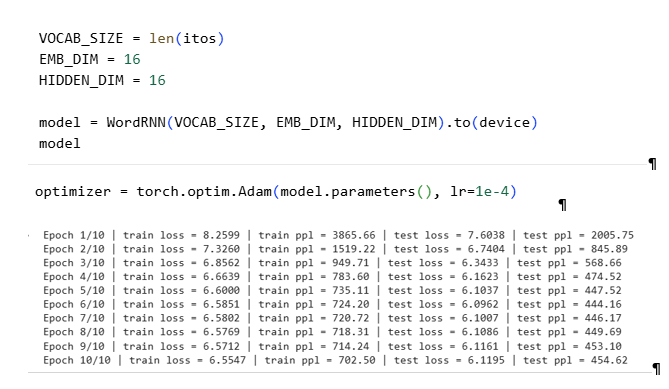

Тест 4 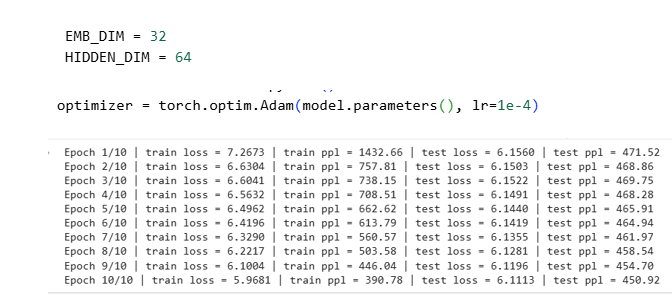

Тест 5 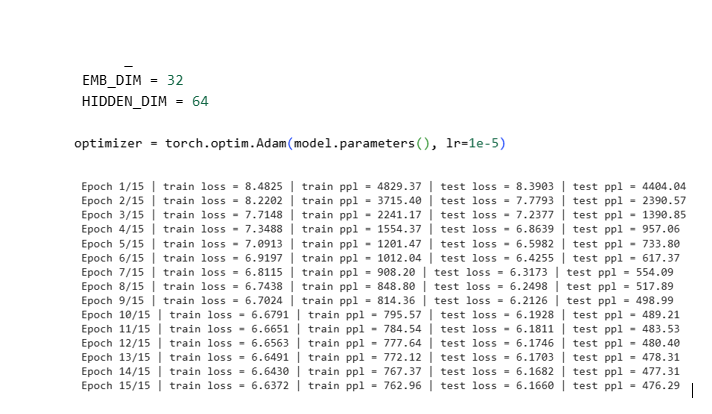

Тест 6
EMB_DIM = 64
HIDDEN_DIM = 128
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

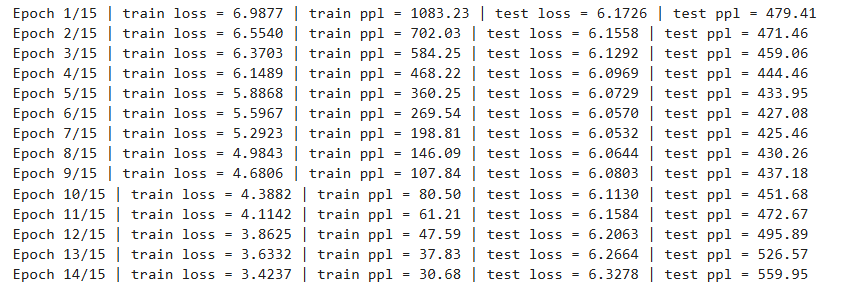

In [92]:
VOCAB_SIZE = len(itos)
EMB_DIM = 64
HIDDEN_DIM = 128

model = WordRNN(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM).to(device)
model

WordRNN(
  (emb): Embedding(5000, 64)
  (rnn): RNN(64, 128, batch_first=True)
  (out): Linear(in_features=128, out_features=5000, bias=True)
)

In [93]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [94]:
xb, yb = next(iter(train_loader))
xb = xb.to(device)
yb = yb.to(device)

logits, h_n = model(xb)

print("logits shape:", logits.shape)  # (B, L, V)
#print("h_n shape:", h_n.shape)        # (1, B, H)

loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
print("loss:", float(loss))

logits shape: torch.Size([32, 30, 5000])
loss: 8.57618236541748


In [95]:
@torch.no_grad()
def evaluate(model, loader, criterion, device, vocab_size):
    model.eval()
    total_loss = 0.0
    total_batches = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits, _ = model(xb)
        loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))

        total_loss += loss.item()
        total_batches += 1

    mean_loss = total_loss / total_batches
    ppl = math.exp(mean_loss)
    return mean_loss, ppl


EPOCHS = 10

train_losses = []
test_losses = []
train_ppls = []
test_ppls = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_ppl = math.exp(train_loss)

    test_loss, test_ppl = evaluate(model, test_loader, criterion, device, VOCAB_SIZE)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_ppls.append(train_ppl)
    test_ppls.append(test_ppl)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train loss = {train_loss:.4f} | train ppl = {train_ppl:.2f} | "
        f"test loss = {test_loss:.4f} | test ppl = {test_ppl:.2f}"
    )

Epoch 1/10 | train loss = 7.0148 | train ppl = 1112.96 | test loss = 6.1690 | test ppl = 477.70
Epoch 2/10 | train loss = 6.5678 | train ppl = 711.80 | test loss = 6.1515 | test ppl = 469.41
Epoch 3/10 | train loss = 6.3856 | train ppl = 593.24 | test loss = 6.1157 | test ppl = 452.92
Epoch 4/10 | train loss = 6.1612 | train ppl = 473.98 | test loss = 6.0832 | test ppl = 438.43
Epoch 5/10 | train loss = 5.8980 | train ppl = 364.31 | test loss = 6.0489 | test ppl = 423.66
Epoch 6/10 | train loss = 5.6104 | train ppl = 273.27 | test loss = 6.0205 | test ppl = 411.77
Epoch 7/10 | train loss = 5.3112 | train ppl = 202.59 | test loss = 6.0157 | test ppl = 409.82
Epoch 8/10 | train loss = 5.0093 | train ppl = 149.80 | test loss = 6.0275 | test ppl = 414.67
Epoch 9/10 | train loss = 4.7112 | train ppl = 111.18 | test loss = 6.0552 | test ppl = 426.31
Epoch 10/10 | train loss = 4.4226 | train ppl = 83.31 | test loss = 6.0916 | test ppl = 442.15


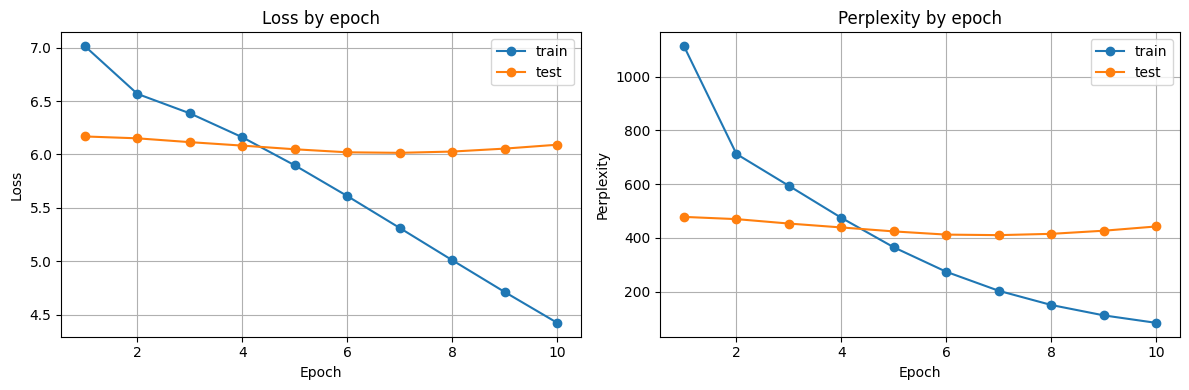

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(train_losses) + 1), train_losses, marker="o", label="train")
axes[0].plot(range(1, len(test_losses) + 1), test_losses, marker="o", label="test")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss by epoch")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(range(1, len(train_ppls) + 1), train_ppls, marker="o", label="train")
axes[1].plot(range(1, len(test_ppls) + 1), test_ppls, marker="o", label="test")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Perplexity")
axes[1].set_title("Perplexity by epoch")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [97]:
def decode_ids(id_list):
    return " ".join(itos[i] for i in id_list)

def sample_from_logits(logits, method="greedy", temperature=1.0, top_k=None):
    """
    logits: tensor of shape (V,)
    """
    logits = logits.detach().cpu()

    if method == "greedy":
        return int(torch.argmax(logits).item())

    # temperature
    logits = logits / temperature

    # top-k
    if top_k is not None:
        values, indices = torch.topk(logits, k=min(top_k, logits.shape[0]))
        probs = torch.softmax(values, dim=0)
        chosen = torch.multinomial(probs, num_samples=1).item()
        return int(indices[chosen].item())

    # plain sampling
    probs = torch.softmax(logits, dim=0)
    return int(torch.multinomial(probs, num_samples=1).item())

In [98]:
@torch.no_grad()
def generate_text(
    model,
    prompt,
    max_new_tokens=30,
    method="greedy",
    temperature=1.0,
    top_k=None
):
    model.eval()

    prompt_tokens = re.findall(r"\w+|[^\w\s]", prompt.lower(), re.UNICODE)
    if len(prompt_tokens) == 0:
        raise ValueError("Prompt is empty after tokenization.")

    input_ids = [stoi.get(tok, UNK_ID) for tok in prompt_tokens]
    generated = input_ids[:]

    # Сначала прогоняем весь prompt, чтобы получить состояние
    x = torch.tensor([generated], dtype=torch.long, device=device)
    logits, h = model(x)

    # Последний логит соответствует предсказанию после последнего токена prompt
    next_logits = logits[0, -1]

    for _ in range(max_new_tokens):
        next_id = sample_from_logits(
            next_logits,
            method=method,
            temperature=temperature,
            top_k=top_k
        )
        generated.append(next_id)

        # Следующий шаг: подаём только последний токен и продолжаем с тем же hidden state
        x_next = torch.tensor([[next_id]], dtype=torch.long, device=device)
        logits, h = model(x_next, h)
        next_logits = logits[0, -1]

    return decode_ids(generated)

In [99]:
prompt = "какую шапку надел"
print(generate_text(model, prompt, max_new_tokens=40, method="greedy"))

какую шапку надел <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>


In [100]:
prompt = "На ярмарке случилось"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling"))

на ярмарке случилось она покойный к этому вскричал глаз на него если сомнения <unk> ступай <unk> <unk> небо свое <unk> другой <unk> подпершись <unk> все с <unk> ногою <unk> <unk> с места <unk> <unk> его хоть бы головы стой <unk> вместо даже комиссар


In [101]:
prompt = "она любит яблоки"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling"))

она любит <unk> на другую теперь бог этого <unk> прощай каким мне <unk> голова <unk> из <unk> петрусь чета от <unk> писарь и привлекала дыма спокойно пожилая по улице да и веяла же и сделала туда что тебе верно пояс <unk> почувствовал на


In [102]:
prompt = "За Фомою Григорьевичем водилась"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling", top_k=10))

за фомою григорьевичем водилась особенного него а я не было из <unk> на <unk> и <unk> и не <unk> на <unk> в <unk> <unk> <unk> к <unk> <unk> и как <unk> на него <unk> <unk> и <unk> <unk> <unk> <unk> на <unk> <unk> его


Наблюдение: Самый первый тест больше всего предсказывал правильно текст произведения, на остальных же обучение не было настолько эффективным, но при этом не происходило переобучения. На последнем тесте 8 было достигли самых лучших показателей по тестовой выборке, но при этом такая модель практически не предсказывет промты

 Чем greedy decoding отличается от sampling?
greedy всегда выбирает токен с максимальной вероятностью, sampling же случайно
 Как влияет temperature?
 temperature влияет на гнерацию, чем меньше температура тем больше разнообразия вероятности
 Что меняется при top-k?
 выбирает наиболее вероятные слова для генерации